In [ ]:
import os

os.makedirs("figures", exist_ok=True)
import lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

In [ ]:
BPI = pd.read_csv("data/BPIntensiveZZ-2.csv")
print(BPI.shape)
BPI.info()
BPI.describe()

(9308, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9308 entries, 0 to 9307
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             9308 non-null   object 
 1   Treat          9308 non-null   int64  
 2   Age            9308 non-null   int64  
 3   Gender         9308 non-null   int64  
 4   Smoking        9297 non-null   float64
 5   Triglycerides  9286 non-null   float64
 6   BMI            9247 non-null   float64
 7   total_DDD      9261 non-null   float64
 8   Death          9308 non-null   int64  
 9   Time           9308 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 727.3+ KB


,Treat,Age,Gender,Smoking,Triglycerides,BMI,total_DDD,Death,Time
count,9308.000000,9308.000000,9308.000000,9297.000000,9286.000000,9247.000000,9261.000000,9308.000000,9308.000000
mean,0.499785,67.885260,0.355393,0.132839,125.961986,29.856788,2.576614,0.040288,3.671146
std,0.500027,9.416873,0.478658,0.339418,89.943515,5.767093,2.104557,0.196644,1.045293
min,0.000000,46.000000,0.000000,0.000000,23.000000,13.734211,0.000000,0.000000,0.000000
25%,0.000000,61.000000,0.000000,0.000000,77.000000,25.881587,1.000000,0.000000,3.300000
50%,0.000000,67.000000,0.000000,0.000000,107.000000,29.023675,2.000000,0.000000,3.800000
75%,1.000000,75.000000,1.000000,0.000000,150.000000,32.914327,3.666667,0.000000,4.350000
max,1.000000,96.000000,1.000000,1.000000,3340.000000,69.591010,22.000000,1.000000,5.490000


Time     0
Death    0
Treat    0
dtype: int64
{'n': 9308, 'events': 375, 'treat_table': {0: 4656, 1: 4652}, 'death_table': {0: 8933, 1: 375}, 'time_range': (np.float64(0.0), np.float64(5.49))}


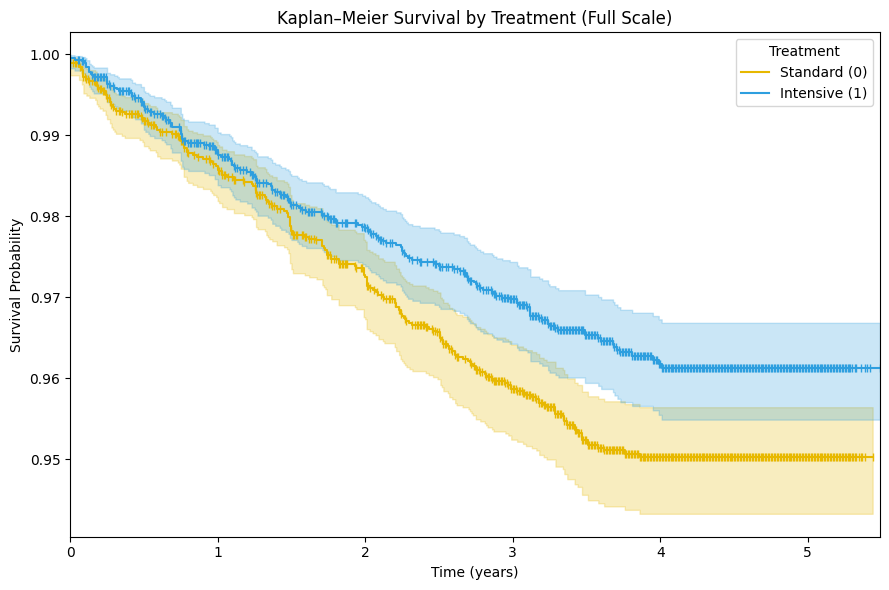

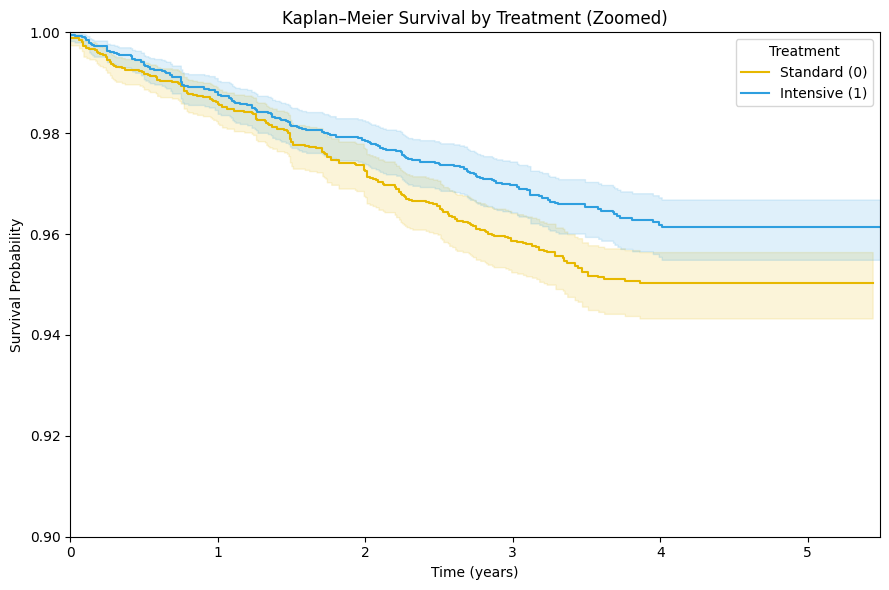

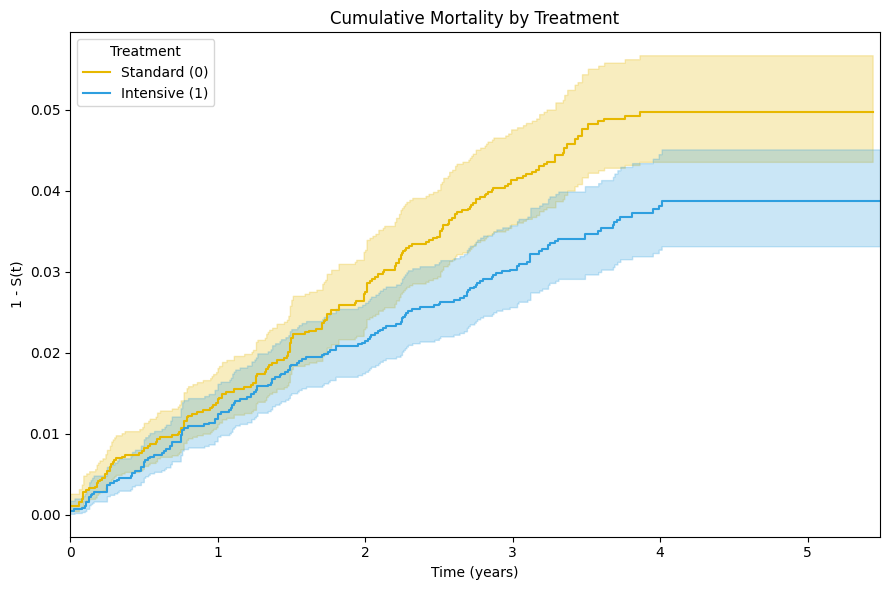

Log-rank chi-sq: 7.182
Log-rank p-value: 0.007364


In [ ]:
# Key survival fields must exist
# Key survival fields must exist
required_cols = ["Time", "Death", "Treat"]
assert all(col in BPI.columns for col in required_cols)

# Basic missingness
print(BPI[required_cols].isna().sum())

# Keep only rows with complete survival fields
BPI_surv = BPI[required_cols].dropna()

# Group balance & event rate
print(
    {
        "n": len(BPI_surv),
        "events": int(BPI_surv["Death"].sum()),
        "treat_table": BPI_surv["Treat"].value_counts().to_dict(),
        "death_table": BPI_surv["Death"].value_counts().to_dict(),
        "time_range": (BPI_surv["Time"].min(), BPI_surv["Time"].max()),
    }
)

# ---- Fit KM model ----
kmf = KaplanMeierFitter()
groups = [(0, "Standard (0)", "#E7B800"), (1, "Intensive (1)", "#2E9FDF")]

# ---- Plot 1: Full-scale KM curve (with censor marks) ----
fig, ax = plt.subplots(figsize=(9, 6))
for treat_value, label, color in groups:
    mask = BPI_surv["Treat"] == treat_value
    kmf.fit(BPI_surv.loc[mask, "Time"], BPI_surv.loc[mask, "Death"], label=label)
    kmf.plot_survival_function(
        ax=ax,
        color=color,
        ci_show=True,
        show_censors=True,
        censor_styles={"marker": "|", "ms": 6},
    )

plt.title("Kaplan–Meier Survival by Treatment (Full Scale)")
plt.xlabel("Time (years)")
plt.ylabel("Survival Probability")
plt.xlim(0, BPI_surv["Time"].max())
plt.legend(title="Treatment")
plt.tight_layout()
plt.savefig("figures/km_curve_full.png", dpi=150)
plt.show()

# ---- Plot 2: Zoomed KM curve ----
fig, ax = plt.subplots(figsize=(9, 6))
for treat_value, label, color in groups:
    mask = BPI_surv["Treat"] == treat_value
    kmf.fit(BPI_surv.loc[mask, "Time"], BPI_surv.loc[mask, "Death"], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)

plt.title("Kaplan–Meier Survival by Treatment (Zoomed)")
plt.xlabel("Time (years)")
plt.ylabel("Survival Probability")
plt.xlim(0, BPI_surv["Time"].max())
plt.ylim(0.90, 1.0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.savefig("figures/km_curve_zoom.png", dpi=150)
plt.show()

# ---- Plot 3: Cumulative mortality (1 - S(t)) ----
fig, ax = plt.subplots(figsize=(9, 6))
for treat_value, label, color in groups:
    mask = BPI_surv["Treat"] == treat_value
    kmf.fit(BPI_surv.loc[mask, "Time"], BPI_surv.loc[mask, "Death"], label=label)
    kmf.plot_cumulative_density(ax=ax, color=color, ci_show=True)

plt.title("Cumulative Mortality by Treatment")
plt.xlabel("Time (years)")
plt.ylabel("1 - S(t)")
plt.xlim(0, BPI_surv["Time"].max())
plt.legend(title="Treatment")
plt.tight_layout()
plt.savefig("figures/cumulative_mortality.png", dpi=150)
plt.show()

# ---- Log-rank test ----
group0 = BPI_surv[BPI_surv["Treat"] == 0]
group1 = BPI_surv[BPI_surv["Treat"] == 1]

lr_result = logrank_test(
    group0["Time"],
    group1["Time"],
    event_observed_A=group0["Death"],
    event_observed_B=group1["Death"],
)
print("Log-rank chi-sq:", round(lr_result.test_statistic, 4))
print("Log-rank p-value:", round(lr_result.p_value, 6))

<lifelines.CoxPHFitter: fitted with 9308 total observations, 8933 right-censored observations>
             duration col = 'Time'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 9308
number of events observed = 375
   partial log-likelihood = -3383.97
         time fit was run = 2026-08-18 01:55:07 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Treat     -0.28      0.76      0.10           -0.48           -0.07                0.62                0.93

           cmp to     z    p  -log2(p)
covariate                             
Treat        0.00 -2.67 0.01      7.05
---
Concordance = 0.54
Partial AIC = 6769.93
log-likelihood ratio test = 7.20 on 1 df
-log2(p) of ll-ratio test = 7.10

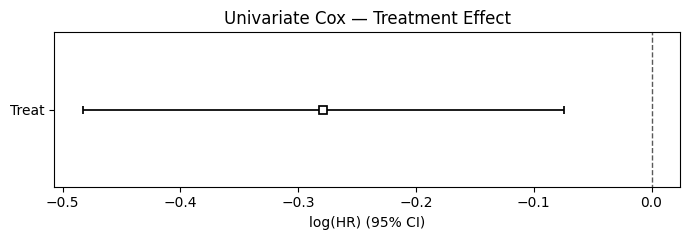

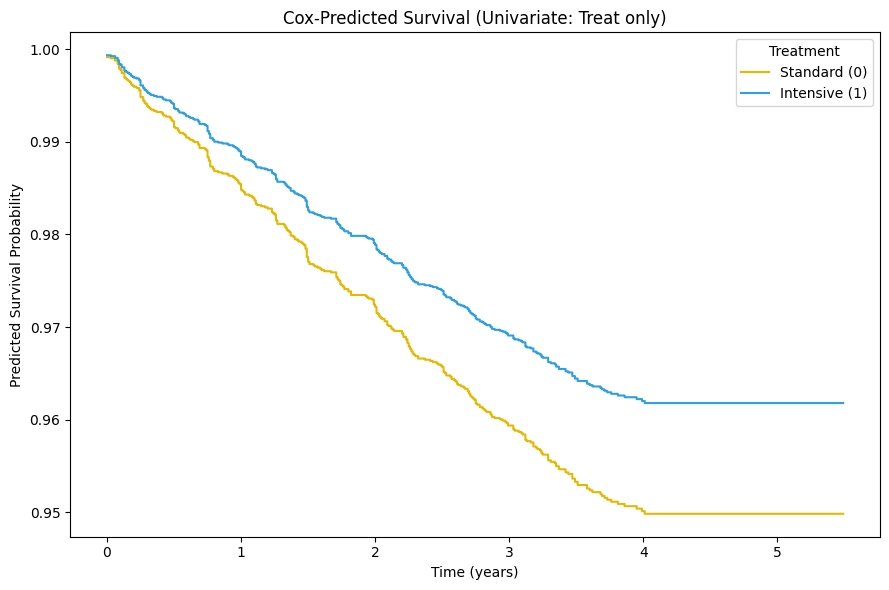

In [ ]:
# ---- Univariate Cox proportional hazards model ----
cph_uni = CoxPHFitter()
cph_uni.fit(BPI_surv, duration_col="Time", event_col="Death", formula="Treat")
cph_uni.print_summary()

# ---- Forest plot (equivalent to ggforest) ----
fig, ax = plt.subplots(figsize=(7, 2.5))
cph_uni.plot(ax=ax)
plt.title("Univariate Cox — Treatment Effect")
plt.tight_layout()
plt.savefig("figures/cox_forest_univariate.png", dpi=150)
plt.show()

# ---- Cox-predicted survival curves for each treatment group ----
newdata = pd.DataFrame({"Treat": [0, 1]})
surv_funcs = cph_uni.predict_survival_function(newdata)

fig, ax = plt.subplots(figsize=(9, 6))
labels = ["Standard (0)", "Intensive (1)"]
colors = ["#E7B800", "#2E9FDF"]

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.step(
        surv_funcs.index, surv_funcs.iloc[:, i], where="post", label=label, color=color
    )

plt.title("Cox-Predicted Survival (Univariate: Treat only)")
plt.xlabel("Time (years)")
plt.ylabel("Predicted Survival Probability")
plt.legend(title="Treatment")
plt.tight_layout()
plt.savefig("figures/cox_predicted_survival.png", dpi=150)
plt.show()

In [ ]:
# ---- Read and prepare data ----
BPI = pd.read_csv("data/BPIntensiveZZ-2.csv")

# Ensure numeric types (defensive)
num_cols = [
    "Treat",
    "Age",
    "Gender",
    "Smoking",
    "Triglycerides",
    "BMI",
    "total_DDD",
    "Death",
    "Time",
]
BPI[num_cols] = BPI[num_cols].apply(pd.to_numeric, errors="coerce")

# Ensure numeric (explicit, matching the R block's redundant-but-safe re-cast)
BPI["Time"] = BPI["Time"].astype(float)
BPI["Death"] = BPI["Death"].astype("Int64")  # should be 0/1, allows NA safely
BPI["Treat"] = BPI["Treat"].astype(float)
BPI["Age"] = BPI["Age"].astype(float)
BPI["Gender"] = BPI["Gender"].astype(float)
BPI["Smoking"] = BPI["Smoking"].astype(float)
BPI["Triglycerides"] = BPI["Triglycerides"].astype(float)
BPI["BMI"] = BPI["BMI"].astype(float)
BPI["total_DDD"] = BPI["total_DDD"].astype(float)

# ---- MULTIVARIATE COX MODEL ----
cox_cols = [
    "Time",
    "Death",
    "Age",
    "Gender",
    "Treat",
    "Smoking",
    "Triglycerides",
    "BMI",
    "total_DDD",
]
BPI_multi = BPI[
    cox_cols
].dropna()  # coxph() in R silently drops rows with missingness too

res_cox = CoxPHFitter()
res_cox.fit(BPI_multi, duration_col="Time", event_col="Death")
res_cox.print_summary()

<lifelines.CoxPHFitter: fitted with 9170 total observations, 8802 right-censored observations>
             duration col = 'Time'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 9170
number of events observed = 368
   partial log-likelihood = -3218.97
         time fit was run = 2026-08-18 01:55:09 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Age            0.08      1.08      0.01            0.07            0.09                1.07                1.10
Gender        -0.42      0.66      0.12           -0.65           -0.19                0.52                0.83
Treat         -0.28      0.75      0.11           -0.49           -0.08                0.61                0.92
Smoking        1.02      2.78      0.15            0.73            1.32                2.08                3.73
Triglycerides  0.00      1.00      0.00            0.00            0.00                1.00                1.00
BMI            0.00      1.00      0.01           -0.02            0.02                0.98                1.02
total_DDD      0.05      1.06      0.02            0.01            0.10                1.01                1.10

               cmp to     z      p  -log2(p)
covariate                                   
Age              0.00 12.31 <0.005    113.33
Gender           0.00 -3.61 <0.005     11.66
Treat            0.00 -2.70   0.01      7.19
Smoking          0.00  6.84 <0.005     36.87
Triglycerides    0.00  2.52   0.01      6.41
BMI              0.00  0.25   0.81      0.31
total_DDD        0.00  2.29   0.02      5.49
---
Concordance = 0.69
Partial AIC = 6451.94
log-likelihood ratio test = 199.30 on 7 df
-log2(p) of ll-ratio test = 128.86

<lifelines.CoxPHFitter: fitted with 9170 total observations, 8802 right-censored observations>
             duration col = 'Time'
                event col = 'Death'
      baseline estimation = breslow
   number of observations = 9170
number of events observed = 368
   partial log-likelihood = -3218.97
         time fit was run = 2026-08-18 01:55:12 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Age            0.08      1.08      0.01            0.07            0.09                1.07                1.10
Gender        -0.42      0.66      0.12           -0.65           -0.19                0.52                0.83
Treat         -0.28      0.75      0.11           -0.49           -0.08                0.61                0.92
Smoking        1.02      2.78      0.15            0.73            1.32                2.08                3.73
Triglycerides  0.00      1.00      0.00            0.00            0.00                1.00                1.00
BMI            0.00      1.00      0.01           -0.02            0.02                0.98                1.02
total_DDD      0.05      1.06      0.02            0.01            0.10                1.01                1.10

               cmp to     z      p  -log2(p)
covariate                                   
Age              0.00 12.31 <0.005    113.33
Gender           0.00 -3.61 <0.005     11.66
Treat            0.00 -2.70   0.01      7.19
Smoking          0.00  6.84 <0.005     36.87
Triglycerides    0.00  2.52   0.01      6.41
BMI              0.00  0.25   0.81      0.31
total_DDD        0.00  2.29   0.02      5.49
---
Concordance = 0.69
Partial AIC = 6451.94
log-likelihood ratio test = 199.30 on 7 df
-log2(p) of ll-ratio test = 128.86


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


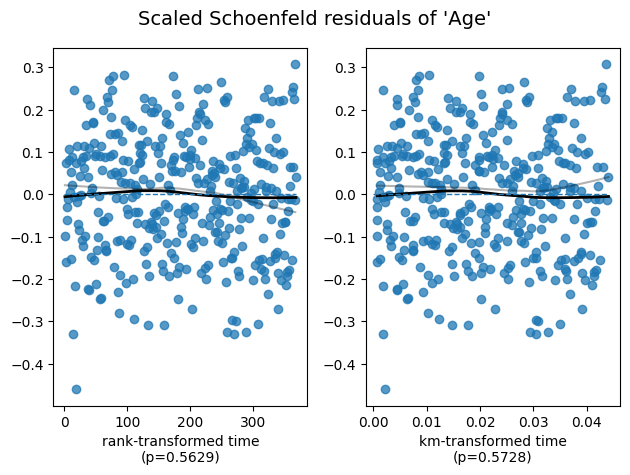

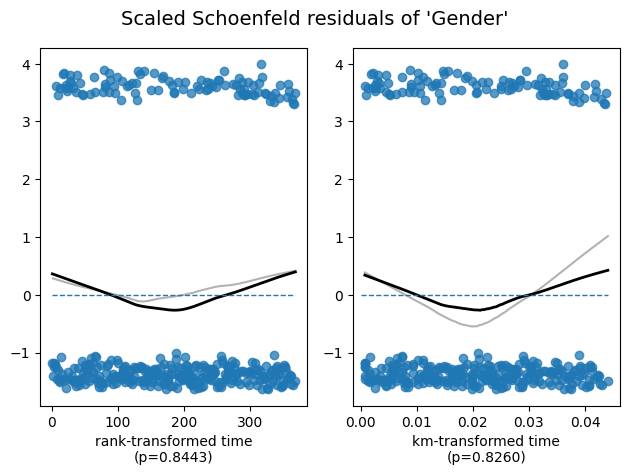

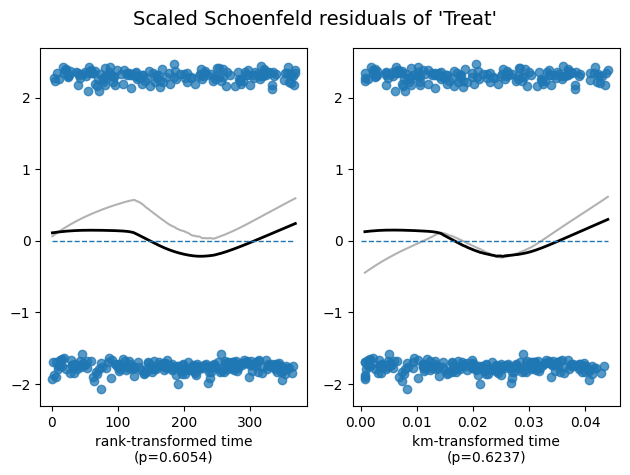

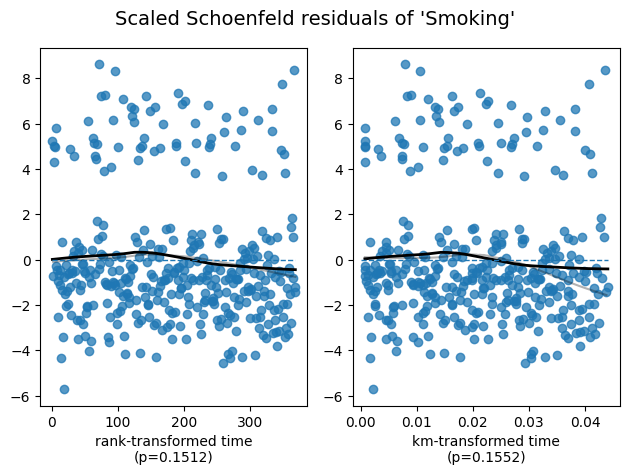

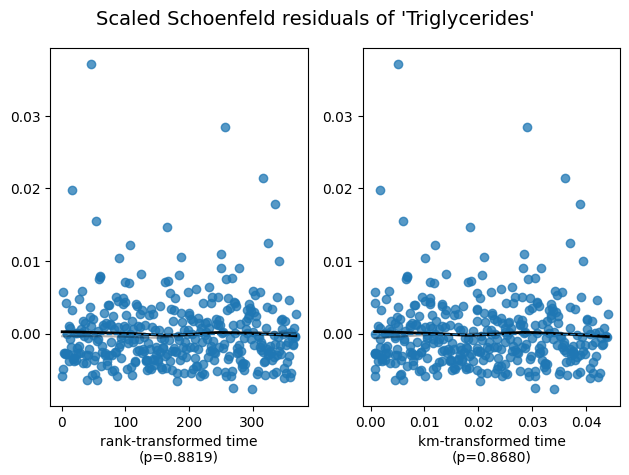

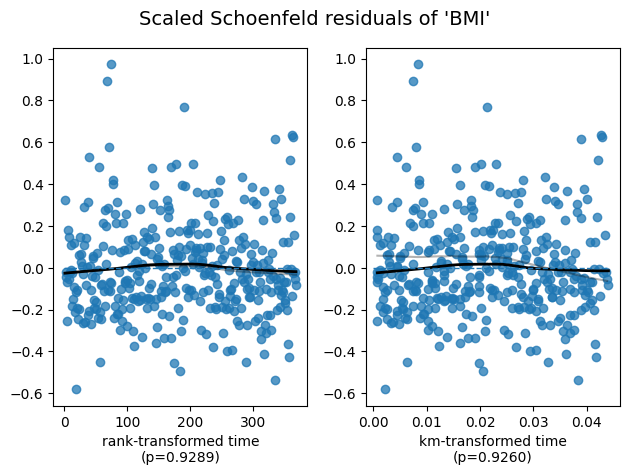

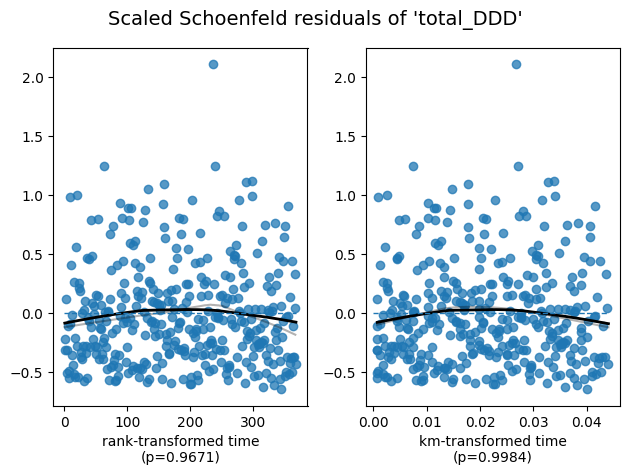

In [ ]:
# ---- Refit multivariate Cox model (as in the R block) ----
cox_cols = [
    "Time",
    "Death",
    "Age",
    "Gender",
    "Treat",
    "Smoking",
    "Triglycerides",
    "BMI",
    "total_DDD",
]
BPI_multi = BPI[cox_cols].dropna()

res_cox = CoxPHFitter()
res_cox.fit(BPI_multi, duration_col="Time", event_col="Death")
res_cox.print_summary()

# ---- Test proportional hazards (PH) assumption ----
# lifelines' check_assumptions() is the equivalent of R's cox.zph():
# it runs a statistical test per covariate AND produces Schoenfeld-residual-style plots.
ph_test_results = res_cox.check_assumptions(
    BPI_multi,
    p_value_threshold=0.05,
    show_plots=True,
    plot_n_bootstraps=1,  # keep plotting fast; increase for smoother residual smoothing lines
)

plt.savefig("figures/ph_diagnostics_all_covariates.png", dpi=150)
plt.show()